In [1]:
# =========================
# Cell 0: imports & config
# =========================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from matplotlib.lines import Line2D

repo_root = Path("/Users/toddywang/Documents/VsCodeProjects/xmltoexp")
data_root = repo_root / "MazurkaBL-master"
beat_time_dir = data_root / "beat_time"

mazurka_id = "M06-1"
beat_time_file = beat_time_dir / f"{mazurka_id}beat_time.csv"

print("beat_time_file:", beat_time_file)
assert beat_time_file.exists(), f"File not found: {beat_time_file}"


# =========================
# Cell 1: load + tempo curves
# =========================
def load_beat_time(file_path: Path):
    df = pd.read_csv(file_path)
    meta_cols = {"Unnamed: 0", "measure_number", "beat_number"}
    performer_cols = [c for c in df.columns if c not in meta_cols]
    beat_index = np.arange(len(df), dtype=int)
    return df, performer_cols, beat_index

def compute_tempo_curves(df, performer_cols, smooth_window=3, bpm_range=(0, 5000), clip_max=600):
    tempo_arrays = {}
    lo, hi = bpm_range

    for col in performer_cols:
        times = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)

        dt = np.diff(times, prepend=np.nan)
        tempo = 60.0 / dt

        invalid = (dt <= 0) | (~np.isfinite(tempo))
        tempo[invalid] = np.nan

        s = pd.Series(tempo)
        s = s.where((s > lo) & (s < hi))
        s = s.interpolate("linear", limit_direction="both")

        s = s.rolling(window=smooth_window, center=True, min_periods=1).mean()
        s = s.clip(upper=clip_max)

        tempo_arrays[col] = s.to_numpy()

    return tempo_arrays

df_bt, performer_cols, beat_index = load_beat_time(beat_time_file)
tempo_arrays = compute_tempo_curves(df_bt, performer_cols, smooth_window=3)

print("beats:", len(beat_index))
print("performers:", len(tempo_arrays))


beat_time_file: /Users/toddywang/Documents/VsCodeProjects/xmltoexp/MazurkaBL-master/beat_time/M06-1beat_time.csv
beats: 337
performers: 34


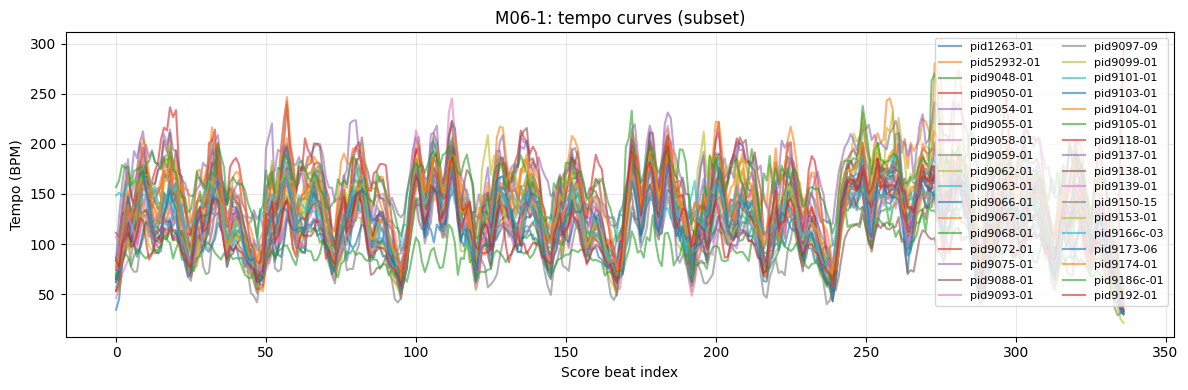

In [3]:
# =========================
# Cell 2: overlay plot (optional)
# =========================
def plot_overlay_tempos(tempo_arrays, n=5, max_beats=None, seed=0):
    if not tempo_arrays:
        print("tempo_arrays is empty.")
        return
    names = list(tempo_arrays.keys())
    if n is not None and n < len(names):
        rng = np.random.default_rng(seed)
        names = list(rng.choice(names, size=n, replace=False))

    plt.figure(figsize=(12, 4))
    for nm in names:
        curve = tempo_arrays[nm]
        if max_beats is not None:
            curve = curve[:max_beats]
        plt.plot(curve, alpha=0.6, label=nm)
    plt.xlabel("Score beat index")
    plt.ylabel("Tempo (BPM)")
    plt.title(f"{mazurka_id}: tempo curves (subset)")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

plot_overlay_tempos(tempo_arrays, n=34, max_beats=400)

In [4]:
# =========================
# Cell 3: (baseline) single-scale boundary detection (your old method)
# =========================
def group_analysis_new(tempo_curve, ws, plot=False, return_pro=False):
    tempo = np.asarray(tempo_curve, dtype=float)
    n = len(tempo)
    ws = int(ws)
    if ws <= 1 or n == 0:
        return np.array([], dtype=int) if not return_pro else (np.array([], dtype=int), tempo * 0)

    # sliding RMS (zero padding)
    if ws % 2 == 1:
        pad_left = (ws - 1) // 2
        pad_right = ws - 1 - pad_left
    else:
        pad_left = ws // 2
        pad_right = ws - pad_left

    padded = np.pad(tempo, (pad_left, pad_right), mode="constant", constant_values=0.0)
    pro = np.zeros(n, dtype=float)

    for i in range(n):
        window = padded[i:i + ws]
        nonzero = window != 0
        if np.any(nonzero):
            pro[i] = np.sqrt(np.sum(window[nonzero] ** 2) / nonzero.sum())
        else:
            pro[i] = 0.0

    # valleys on pro = peaks on -pro
    min_width = int(np.ceil(ws / 2))
    peaks, _ = find_peaks(-pro, distance=min_width)

    if len(peaks) == 0:
        return np.array([], dtype=int) if not return_pro else (np.array([], dtype=int), pro)

    # refine: local minimum on original tempo
    locs = []
    half = (ws - 1) // 2 if (ws % 2 == 1) else ws // 2
    for p in peaks:
        left = max(0, p - half)
        right = min(n - 1, p + half)
        segment = tempo[left:right + 1]
        if segment.size == 0:
            continue
        locs.append(left + int(np.nanargmin(segment)))

    locs = np.array(sorted(set(locs)), dtype=int)

    if plot:
        fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
        axes[0].plot(pro, label="RMS (pro)")
        axes[0].set_ylabel("RMS")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(tempo, label="tempo")
        axes[1].stem(locs, tempo[locs], linefmt="C1-", markerfmt="C1o", basefmt=" ", label="boundaries")
        axes[1].set_xlabel("Score beat index")
        axes[1].set_ylabel("Tempo")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return (locs, pro) if return_pro else locs

# =========================
# Cell 4: hierarchical boundary detection (thesis/MATLAB-style)
# =========================
def _pad_to_multiple(x, m):
    x = np.asarray(x, dtype=float).reshape(-1)
    pad = (-len(x)) % m
    if pad == 0:
        return x
    return np.concatenate([x, np.zeros(pad, dtype=float)])

def group_analysis_hierarchy(tempo_curve, str_vec, enforce_nested=True):
    """
    Block-hierarchy + trace:
      - Level 1 groups beats into blocks of size str_vec[0]
      - Level i>=2 computes eng2 per block: RMS(norm) - std(norm), finds valleys on eng2
      - Trace from top-level valleys down to beat indices
    Returns:
      results_raw: (L, N) bool, row t means boundaries traced from top=t (1..L)
      level_sets: dict level->np.array beat indices
                 if enforce_nested=True: B_L ⊆ ... ⊆ B_1, with L=coarsest, 1=finest
    """
    tempo = np.asarray(tempo_curve, dtype=float).reshape(-1)
    N = len(tempo)
    str_vec = np.asarray(str_vec, dtype=int).reshape(-1)
    L = len(str_vec)

    if N == 0:
        return np.zeros((L, 0), dtype=bool), {l: np.array([], dtype=int) for l in range(1, L+1)}

    avg = np.nanmean(tempo)
    if not np.isfinite(avg) or avg == 0:
        avg = 1.0

    # 1-indexed containers
    energy  = [None] * (L + 1)
    energy2 = [None] * (L + 1)
    valleys = [None] * (L + 1)

    # Level 1 blocks
    s1 = int(str_vec[0])
    pad_raw  = _pad_to_multiple(tempo, s1)
    pad_norm = _pad_to_multiple(tempo / avg, s1)

    energy[1]  = pad_raw.reshape((s1, -1), order="F")
    energy2[1] = pad_norm.reshape((s1, -1), order="F")

    # Level 1 valleys: beat-level minima on tempo
    v1, _ = find_peaks(-tempo)
    valleys[1] = v1 + 1  # 1-based

    # Higher levels
    for i in range(2, L + 1):
        t_eng = energy[i - 1].copy()
        t_eng[t_eng == 0] = np.nan

        t_norm = t_eng / avg
        eng2 = np.sqrt(np.nanmean(t_norm ** 2, axis=0)) - np.nanstd(t_norm, axis=0)

        vi, _ = find_peaks(-eng2)    # valleys on block sequence
        valleys[i] = vi + 1

        si = int(str_vec[i - 1])
        eng2_pad = _pad_to_multiple(eng2, si)

        # store for next trace step
        energy[i]  = _pad_to_multiple(np.sqrt(np.nanmean(t_eng ** 2, axis=0)), si).reshape((si, -1), order="F")
        energy2[i] = eng2_pad.reshape((si, -1), order="F")

    # Trace from each top level to beats
    results_raw = np.zeros((L, N), dtype=bool)

    for top in range(L, 0, -1):
        roots = valleys[top]
        if roots is None or len(roots) == 0:
            continue

        trace = np.zeros((top, len(roots)), dtype=int)
        trace[0, :] = roots  # 1-based

        for rj in range(len(roots)):
            for i in range(2, top + 1):
                lvl = top + 1 - i
                parent_col = trace[i - 2, rj]
                colvec = energy2[lvl][:, parent_col - 1]
                row = int(np.nanargmin(colvec)) + 1
                trace[i - 1, rj] = int(str_vec[lvl - 1]) * (parent_col - 1) + row

        beats_1b = trace[top - 1, :]
        beats_0b = beats_1b - 1
        beats_0b = beats_0b[(beats_0b >= 0) & (beats_0b < N)]
        results_raw[top - 1, beats_0b] = True

    # raw sets
    level_sets = {l: np.where(results_raw[l-1])[0] for l in range(1, L+1)}

    # nested sets: B_l = union_{t=l..L} raw(t)
    if enforce_nested:
        cum = np.zeros(N, dtype=bool)
        nested = {}
        for l in range(L, 0, -1):
            cum |= results_raw[l-1]
            nested[l] = np.where(cum)[0]
        level_sets = nested

    return results_raw, level_sets


In [5]:
# =========================
# Cell 5: visualization (single performer) - clearer legend/levels
# =========================
def plot_hierarchy_on_tempo(tempo_curve, level_sets, title="", max_beats=400):
    tempo = np.asarray(tempo_curve, dtype=float)
    n = min(len(tempo), max_beats)
    tempo = tempo[:n]
    L = max(level_sets.keys())
    y0, y1 = np.nanmin(tempo), np.nanmax(tempo)

    fig, ax = plt.subplots(1, 1, figsize=(14, 4))
    ax.plot(tempo, alpha=0.9, linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel("Score beat index")
    ax.set_ylabel("Tempo (BPM)")
    ax.grid(alpha=0.3)

    linestyles = ["-", "--", "-.", ":", (0, (5, 2, 1, 2)), (0, (1, 1))]
    handles = []

    for l in range(L, 0, -1):
        xs = np.asarray(level_sets[l], dtype=int)
        xs = xs[xs < n]
        if xs.size == 0:
            continue

        lw = 0.8 + 1.2 * (l / L)
        alpha = 0.12 + 0.70 * (l / L)
        ls = linestyles[(L - l) % len(linestyles)]

        # coarse levels drawn only in upper region (avoid clutter)
        if l >= L - 1:
            yy0 = y0 + 0.55 * (y1 - y0)
        elif l >= L - 3:
            yy0 = y0 + 0.25 * (y1 - y0)
        else:
            yy0 = y0

        ax.vlines(xs, ymin=yy0, ymax=y1, linewidth=lw, alpha=alpha, linestyles=ls)
        handles.append(Line2D([0], [0], color="C1", lw=lw, alpha=alpha, linestyle=ls, label=f"Level {l}"))

    # legend
    ax.legend(handles=handles, ncol=3, fontsize=9, frameon=False, loc="upper right")
    plt.tight_layout()
    plt.show()

def plot_hierarchy_raster(level_sets, n_beats, title="", max_beats=400):
    n = min(n_beats, max_beats)
    L = max(level_sets.keys())
    mat = np.zeros((L, n), dtype=float)
    for l in range(1, L+1):
        xs = np.asarray(level_sets[l], dtype=int)
        xs = xs[xs < n]
        mat[l-1, xs] = l / L  # weight: coarse brighter

    # show level L at top for readability
    mat_show = mat[::-1, :]
    ylabels = [f"L{l}" for l in range(L, 0, -1)]

    plt.figure(figsize=(14, 3.8))
    plt.imshow(mat_show, aspect="auto", interpolation="nearest")
    plt.yticks(np.arange(L), ylabels)
    plt.xlabel("Score beat index")
    plt.title(title)
    plt.tight_layout()
    plt.show()

n performers: 34
first 10: ['pid1263-01', 'pid52932-01', 'pid9048-01', 'pid9050-01', 'pid9054-01', 'pid9055-01', 'pid9058-01', 'pid9059-01', 'pid9062-01', 'pid9063-01']


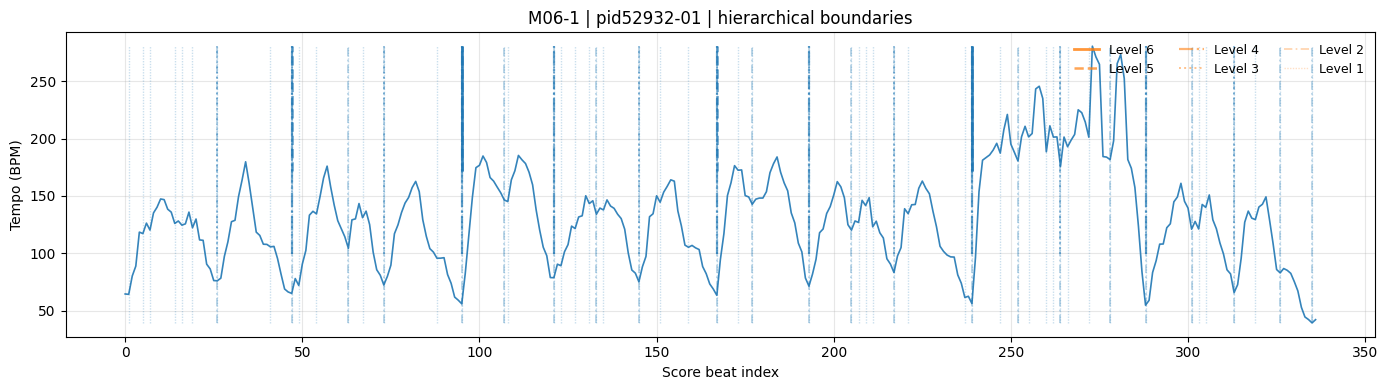

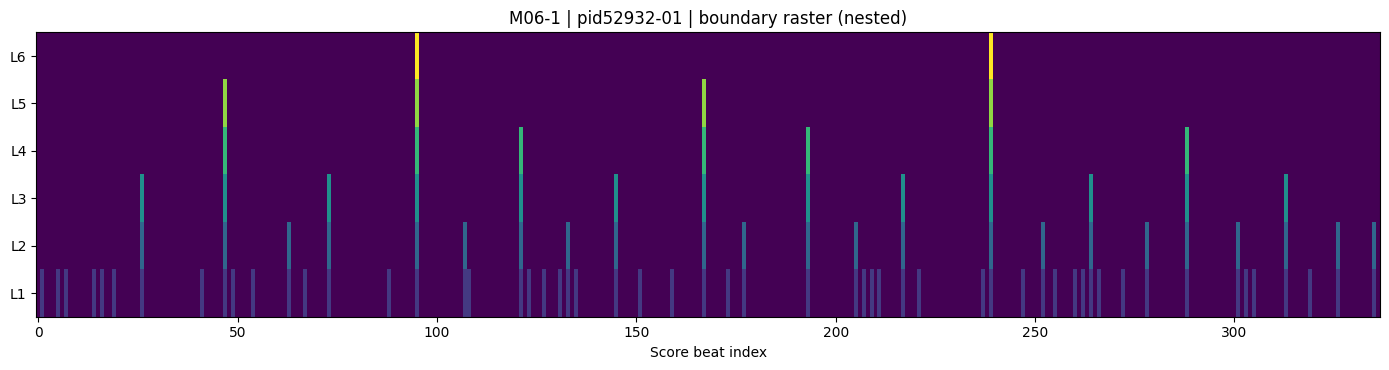

In [6]:
# =========================
# Cell 6: run hierarchy on one performer + plot
# =========================
str_vec = [3,2,2,2,2,2]  # 6 levels

names = list(tempo_arrays.keys())
print("n performers:", len(names))
print("first 10:", names[:10])

one_name = names[1]   # change this index to view a different performer
curve = tempo_arrays[one_name]

results_raw, level_sets = group_analysis_hierarchy(curve, str_vec, enforce_nested=True)

plot_hierarchy_on_tempo(curve, level_sets, title=f"{mazurka_id} | {one_name} | hierarchical boundaries", max_beats=400)
plot_hierarchy_raster(level_sets, n_beats=len(curve), title=f"{mazurka_id} | {one_name} | boundary raster (nested)", max_beats=400)


In [7]:
# =========================
# Cell 7: aggregate across all performers
# =========================
def aggregate_levels_across_performers(tempo_arrays, str_vec, max_beats=None, enforce_nested=True):
    names = list(tempo_arrays.keys())
    n_perf = len(names)
    n_beats = len(next(iter(tempo_arrays.values())))
    if max_beats is not None:
        n_beats = min(n_beats, int(max_beats))
    L = len(str_vec)

    counts = np.zeros((L, n_beats), dtype=int)
    per_perf_levels = {}

    for nm in names:
        curve = tempo_arrays[nm]
        if max_beats is not None:
            curve = curve[:n_beats]
        _, level_sets = group_analysis_hierarchy(curve, str_vec, enforce_nested=enforce_nested)
        per_perf_levels[nm] = level_sets
        for l in range(1, L+1):
            xs = np.asarray(level_sets[l], dtype=int)
            xs = xs[(xs >= 0) & (xs < n_beats)]
            counts[l-1, xs] += 1

    freq = counts / max(n_perf, 1)
    return counts, freq, per_perf_levels

counts, freq, per_perf_levels = aggregate_levels_across_performers(tempo_arrays, str_vec, max_beats=400, enforce_nested=True)
print("aggregate done. freq shape:", freq.shape)




aggregate done. freq shape: (6, 337)


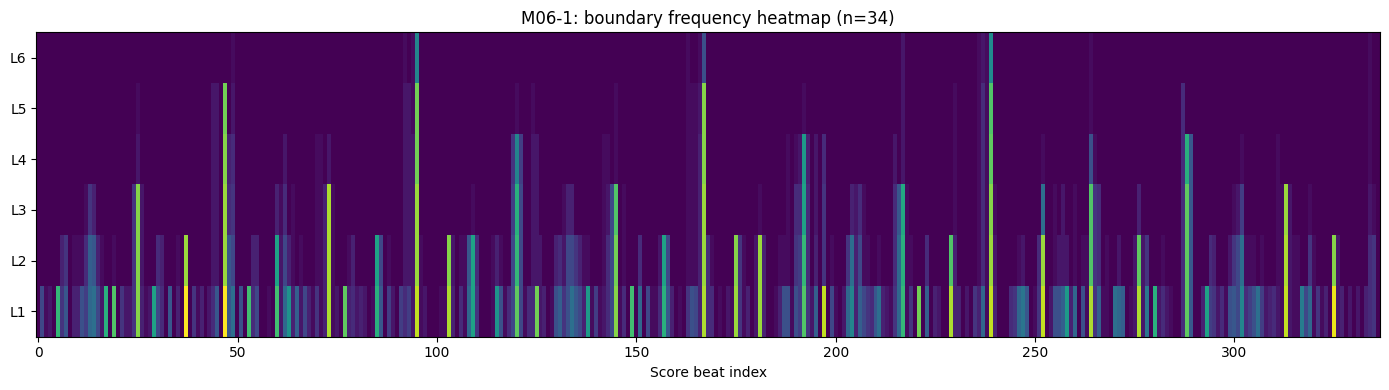

In [8]:
# =========================
# Cell 8: visualize aggregation - heatmap
# =========================
def plot_boundary_heatmap(freq, title="boundary frequency heatmap", show_levels_top_down=True):
    L, N = freq.shape
    mat = freq
    if show_levels_top_down:
        mat = mat[::-1, :]
        ylabels = [f"L{l}" for l in range(L, 0, -1)]
    else:
        ylabels = [f"L{l}" for l in range(1, L+1)]

    plt.figure(figsize=(14, 4))
    plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.yticks(np.arange(L), ylabels)
    plt.xlabel("Score beat index")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_boundary_heatmap(freq, title=f"{mazurka_id}: boundary frequency heatmap (n={len(tempo_arrays)})")



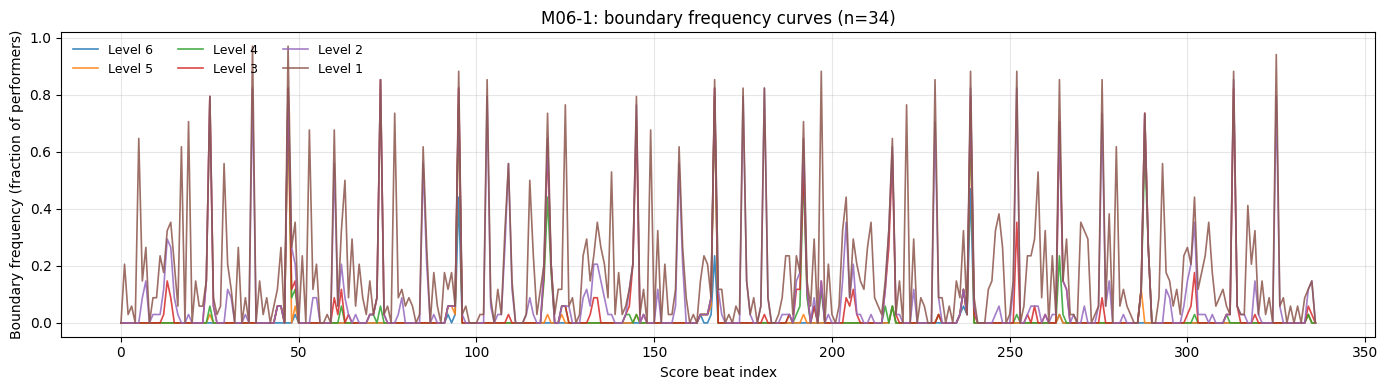

In [9]:
# =========================
# Cell 9: visualize aggregation - per-level frequency curves
# =========================
def plot_level_frequency_curves(freq, title="boundary frequency curves"):
    L, N = freq.shape
    plt.figure(figsize=(14, 4))
    for l in range(L, 0, -1):
        plt.plot(freq[l-1, :], linewidth=1.2, alpha=0.85, label=f"Level {l}")
    plt.xlabel("Score beat index")
    plt.ylabel("Boundary frequency (fraction of performers)")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(ncol=3, fontsize=9, frameon=False)
    plt.tight_layout()
    plt.show()

plot_level_frequency_curves(freq, title=f"{mazurka_id}: boundary frequency curves (n={len(tempo_arrays)})")


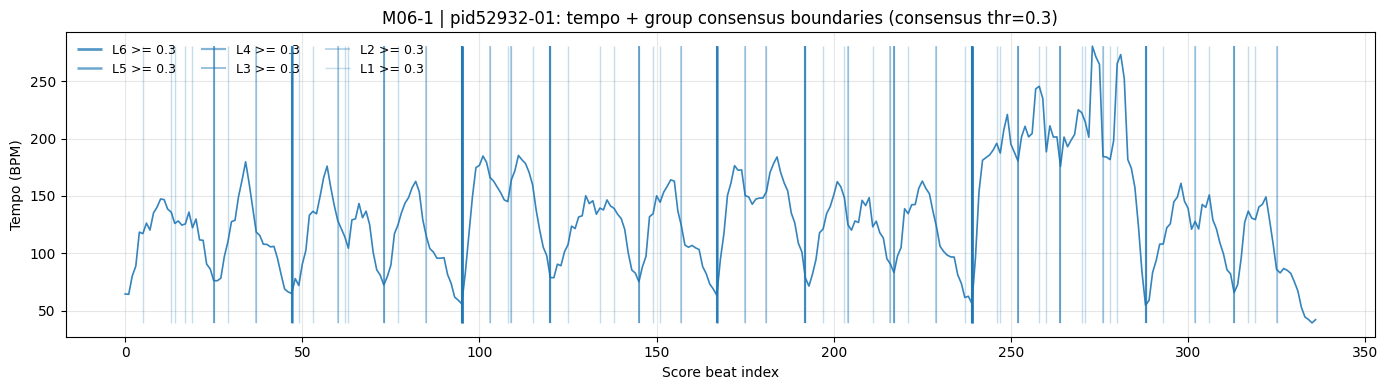

In [10]:
# =========================
# Cell 10: overlay consensus boundaries on one performer's tempo
# =========================
def plot_consensus_on_tempo(tempo_curve, freq, title="", thr=0.3):
    tempo = np.asarray(tempo_curve, dtype=float)
    n = min(len(tempo), freq.shape[1])
    tempo = tempo[:n]

    L = freq.shape[0]
    y0, y1 = np.nanmin(tempo), np.nanmax(tempo)

    fig, ax = plt.subplots(1, 1, figsize=(14, 4))
    ax.plot(tempo, alpha=0.9, linewidth=1.2)
    ax.set_title(title + f" (consensus thr={thr})")
    ax.set_xlabel("Score beat index")
    ax.set_ylabel("Tempo (BPM)")
    ax.grid(alpha=0.3)

    for l in range(L, 0, -1):
        xs = np.where(freq[l-1, :n] >= thr)[0]
        if xs.size == 0:
            continue
        lw = 0.8 + 1.2*(l/L)
        alpha = 0.15 + 0.60*(l/L)
        ax.vlines(xs, ymin=y0, ymax=y1, linewidth=lw, alpha=alpha, label=f"L{l} >= {thr}")

    ax.legend(ncol=3, fontsize=9, frameon=False)
    plt.tight_layout()
    plt.show()

plot_consensus_on_tempo(
    tempo_arrays[one_name],
    freq,
    title=f"{mazurka_id} | {one_name}: tempo + group consensus boundaries",
    thr=0.3
)

In [11]:
import numpy as np
import pandas as pd
from pathlib import Path

# 你要的层级
STR_VEC = [3,2,2,2,2,2]
LEVELS = list(range(1, len(STR_VEC)+1))

def compute_level_counts_for_one_piece(
    beat_time_file: Path,
    str_vec=STR_VEC,
    smooth_window=3,
    bpm_range=(0, 5000),
    clip_max=600,
    enforce_nested=True
):
    """
    返回：
      df_counts: index=performer, columns=Level1..LevelL，每格=该演奏者该层断句数
      series_mean: index=Level1..LevelL，每层跨演奏者平均断句数
      meta: dict with mazurka_id, n_beats, n_performers
    """
    df_bt, performer_cols, beat_index = load_beat_time(beat_time_file)
    tempo_arrays = compute_tempo_curves(
        df_bt, performer_cols,
        smooth_window=smooth_window, bpm_range=bpm_range, clip_max=clip_max
    )

    L = len(str_vec)
    counts = {}
    n_beats = len(beat_index)

    for nm, curve in tempo_arrays.items():
        # hierarchy
        _, level_sets = group_analysis_hierarchy(curve, str_vec, enforce_nested=enforce_nested)
        # count boundaries per level
        counts[nm] = {f"Level{l}": int(len(level_sets[l])) for l in range(1, L+1)}

    df_counts = pd.DataFrame.from_dict(counts, orient="index").sort_index()
    # 确保列顺序
    df_counts = df_counts[[f"Level{l}" for l in range(1, L+1)]]

    series_mean = df_counts.mean(axis=0)

    meta = {
        "piece_id": beat_time_file.stem.replace("beat_time", ""),
        "n_beats": n_beats,
        "n_performers": len(df_counts),
        "file": str(beat_time_file),
    }
    return df_counts, series_mean, meta


def compute_across_pieces_average(
    beat_time_dir: Path,
    piece_ids=None,     # e.g., ["M06-1","M07-1"]; None => all *beat_time.csv
    str_vec=STR_VEC,
    **kwargs
):
    """
    多曲统计：
      piece_level_means: DataFrame，index=piece_id，columns=Level1..LevelL（每首曲子先对演奏者求均值）
      across_piece_mean: Series，index=Level1..LevelL（再对曲子求均值）
      across_piece_std:  Series，曲子间标准差（可选但很有用）
    """
    if piece_ids is None:
        files = sorted(beat_time_dir.glob("*beat_time.csv"))
    else:
        files = [beat_time_dir / f"{pid}beat_time.csv" for pid in piece_ids]
        missing = [f for f in files if not f.exists()]
        if missing:
            raise FileNotFoundError(f"Missing files: {missing}")

    rows = []
    for f in files:
        df_counts, series_mean, meta = compute_level_counts_for_one_piece(
            f, str_vec=str_vec, **kwargs
        )
        row = {"piece_id": meta["piece_id"], "n_beats": meta["n_beats"], "n_performers": meta["n_performers"]}
        row.update(series_mean.to_dict())  # Level1..LevelL mean counts per performer for this piece
        rows.append(row)

    piece_level_means = pd.DataFrame(rows).set_index("piece_id").sort_index()
    level_cols = [f"Level{l}" for l in range(1, len(str_vec)+1)]
    across_piece_mean = piece_level_means[level_cols].mean(axis=0)
    across_piece_std  = piece_level_means[level_cols].std(axis=0, ddof=1)

    return piece_level_means, across_piece_mean, across_piece_std


In [12]:
# 例如 mazurka_id = "M06-1"
beat_time_file = beat_time_dir / f"{mazurka_id}beat_time.csv"

df_counts, level_mean, meta = compute_level_counts_for_one_piece(beat_time_file)

print(meta)
print("\nPer-performer counts (head):")
print(df_counts.head(10))

print("\nMean counts across performers (per level):")
print(level_mean)

{'piece_id': 'M06-1', 'n_beats': 337, 'n_performers': 34, 'file': '/Users/toddywang/Documents/VsCodeProjects/xmltoexp/MazurkaBL-master/beat_time/M06-1beat_time.csv'}

Per-performer counts (head):
             Level1  Level2  Level3  Level4  Level5  Level6
pid1263-01       73      30      16       8       4       1
pid52932-01      56      23      13       7       4       2
pid9048-01       67      35      15       6       3       1
pid9050-01       61      33      16       8       5       3
pid9054-01       58      27      16       8       5       1
pid9055-01       53      38      22       9       4       1
pid9058-01       50      31      19       9       4       2
pid9059-01       64      30      16       8       4       2
pid9062-01       52      30      13       7       4       2
pid9063-01       62      32      13       7       4       2

Mean counts across performers (per level):
Level1    62.882353
Level2    31.470588
Level3    15.617647
Level4     7.588235
Level5     4.088235


In [13]:
piece_level_means, across_piece_mean, across_piece_std = compute_across_pieces_average(beat_time_dir)

print("\nPer-piece mean counts (each piece averaged over performers):")
print(piece_level_means.head())

print("\nAcross-piece mean (average of per-piece means):")
print(across_piece_mean)

print("\nAcross-piece std (variation across pieces):")
print(across_piece_std)


Per-piece mean counts (each piece averaged over performers):
          n_beats  n_performers     Level1     Level2     Level3    Level4  \
piece_id                                                                     
M06-1         337            34  62.882353  31.470588  15.617647  7.588235   
M06-2         288            42  48.904762  25.119048  12.928571  7.000000   
M06-3         294            42  67.809524  30.047619  15.357143  7.761905   
M06-4         121            39  23.615385  11.641026   6.666667  2.410256   
M07-1         312            41  63.292683  29.195122  16.073171  7.439024   

            Level5    Level6  
piece_id                      
M06-1     4.088235  1.529412  
M06-2     3.357143  0.928571  
M06-3     3.119048  1.404762  
M06-4     1.282051  0.051282  
M07-1     4.000000  1.756098  

Across-piece mean (average of per-piece means):
Level1    66.948140
Level2    31.246678
Level3    16.297148
Level4     7.858650
Level5     3.478302
Level6     1.296955
dtype

In [14]:
import numpy as np
import pandas as pd
from itertools import combinations

def pairwise_overlap_counts(per_perf_levels, levels):
    """
    per_perf_levels: dict performer -> {level -> np.array(boundary_indices)}
    levels: list of levels, e.g. [1,2,3,4,5,6]
    Returns:
      overlaps_by_level: dict level -> DataFrame (performer x performer) with |intersection| counts
      summary_by_level: DataFrame with mean/median/min/max overlap across pairs for each level
    """
    performers = sorted(per_perf_levels.keys())
    P = len(performers)

    overlaps_by_level = {}
    summary_rows = []

    # preconvert to sets for speed
    sets = {nm: {l: set(map(int, per_perf_levels[nm][l])) for l in levels} for nm in performers}

    for l in levels:
        mat = np.zeros((P, P), dtype=int)
        for i in range(P):
            si = sets[performers[i]][l]
            mat[i, i] = len(si)
            for j in range(i+1, P):
                sj = sets[performers[j]][l]
                inter = len(si & sj)
                mat[i, j] = inter
                mat[j, i] = inter

        df_mat = pd.DataFrame(mat, index=performers, columns=performers)
        overlaps_by_level[l] = df_mat

        # summarize off-diagonal pairs
        pair_vals = [mat[i, j] for i in range(P) for j in range(i+1, P)]
        if len(pair_vals) == 0:
            stats = {"level": l, "n_pairs": 0, "mean_overlap": np.nan, "median_overlap": np.nan,
                     "min_overlap": np.nan, "max_overlap": np.nan}
        else:
            pair_vals = np.asarray(pair_vals, dtype=float)
            stats = {"level": l, "n_pairs": len(pair_vals),
                     "mean_overlap": float(np.mean(pair_vals)),
                     "median_overlap": float(np.median(pair_vals)),
                     "min_overlap": float(np.min(pair_vals)),
                     "max_overlap": float(np.max(pair_vals))}
        summary_rows.append(stats)

    summary_by_level = pd.DataFrame(summary_rows).set_index("level")
    return overlaps_by_level, summary_by_level


In [15]:
# 单曲：先算 per_perf_levels
beat_time_file = beat_time_dir / f"{mazurka_id}beat_time.csv"
df_counts, level_mean, meta = compute_level_counts_for_one_piece(beat_time_file)

# 需要 per_perf_levels：我们再跑一次，直接从 tempo_arrays 得到
df_bt, performer_cols, beat_index = load_beat_time(beat_time_file)
tempo_arrays = compute_tempo_curves(df_bt, performer_cols, smooth_window=3)

str_vec = [3,2,2,2,2,2]
levels = list(range(1, len(str_vec)+1))

per_perf_levels = {}
for nm, curve in tempo_arrays.items():
    _, level_sets = group_analysis_hierarchy(curve, str_vec, enforce_nested=True)
    per_perf_levels[nm] = level_sets

overlaps_by_level, summary_by_level = pairwise_overlap_counts(per_perf_levels, levels)

print("Pairwise overlap summary (counts) per level:")
print(summary_by_level)


Pairwise overlap summary (counts) per level:
       n_pairs  mean_overlap  median_overlap  min_overlap  max_overlap
level                                                                 
1          561     29.217469            29.0         10.0         45.0
2          561     15.345811            16.0          3.0         28.0
3          561      7.846702             8.0          1.0         14.0
4          561      3.442068             4.0          0.0          8.0
5          561      2.310160             3.0          0.0          5.0
6          561      0.454545             0.0          0.0          2.0


Fitted params on M06-1:
beta = [c, A1..A6] = [ 58.26457232 -11.47328964 -19.01277123 -37.8299042  -26.5255165
  -7.52739794  -4.4281823 ]
M06-1 fit metrics: {'rmse': 15.786480434439484, 'corr': 0.8035254925191467}
M06-2 test metrics (same params): {'rmse': 17.764997589413543, 'corr': 0.7405466489261876}


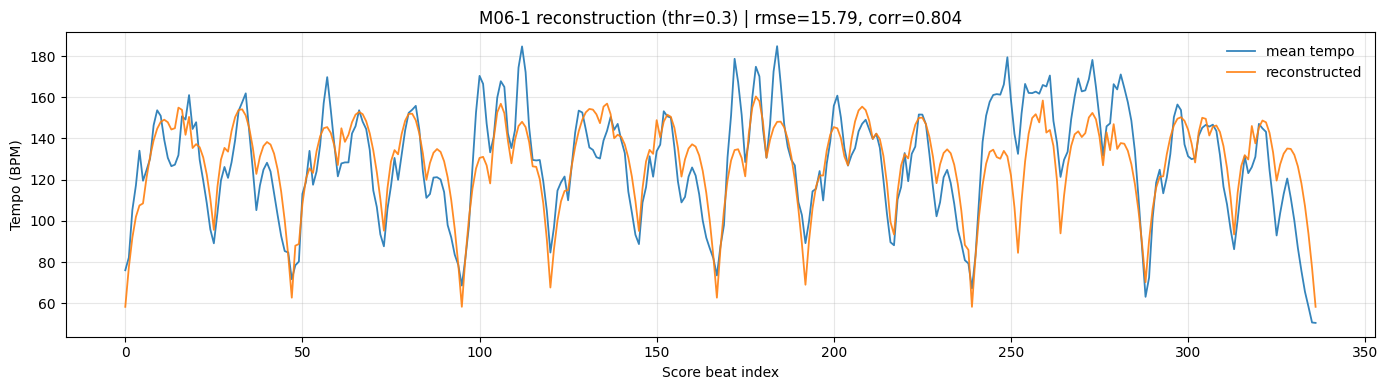

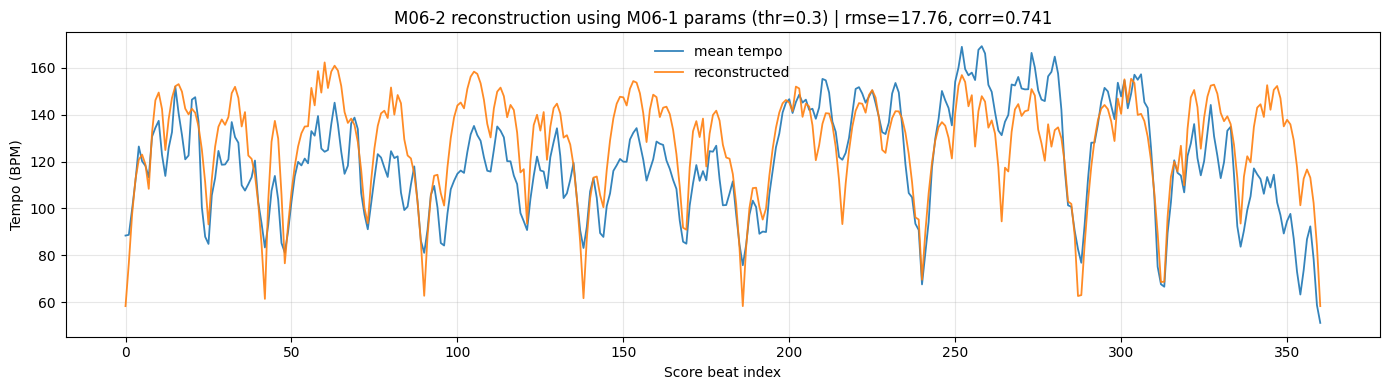

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# helpers: load piece -> mean tempo across performers
# -------------------------
def load_piece_mean_tempo(beat_time_dir, piece_id, smooth_window=3, bpm_range=(0, 5000), clip_max=600):
    f = beat_time_dir / f"{piece_id}beat_time.csv"
    df_bt, performer_cols, beat_index = load_beat_time(f)
    tempo_arrays = compute_tempo_curves(df_bt, performer_cols, smooth_window=smooth_window,
                                        bpm_range=bpm_range, clip_max=clip_max)
    names = list(tempo_arrays.keys())
    mat = np.vstack([tempo_arrays[nm] for nm in names])  # [P, N]
    mean_tempo = np.nanmean(mat, axis=0)
    return mean_tempo, tempo_arrays, names

# -------------------------
# consensus boundaries per level (optional but recommended)
# -------------------------
def consensus_level_sets(tempo_arrays, str_vec, thr=0.3, enforce_nested=True):
    """
    Build one boundary set per level by voting across performers.
    thr: fraction of performers required at a beat to be a boundary at that level.
    Returns: level_sets dict {level->np.array(sorted beat idx)} and freq matrix [L,N].
    """
    names = list(tempo_arrays.keys())
    P = len(names)
    N = len(next(iter(tempo_arrays.values())))
    L = len(str_vec)

    counts = np.zeros((L, N), dtype=int)
    for nm in names:
        _, level_sets_nm = group_analysis_hierarchy(tempo_arrays[nm], str_vec, enforce_nested=enforce_nested)
        for l in range(1, L+1):
            idx = np.asarray(level_sets_nm[l], dtype=int)
            idx = idx[(idx >= 0) & (idx < N)]
            counts[l-1, idx] += 1

    freq = counts / max(P, 1)
    level_sets = {}
    for l in range(1, L+1):
        idx = np.where(freq[l-1] >= thr)[0]
        level_sets[l] = idx.astype(int)

    # ensure nested if desired (strictly)
    if enforce_nested:
        cum = np.zeros(N, dtype=bool)
        nested = {}
        for l in range(L, 0, -1):
            cur = np.zeros(N, dtype=bool)
            cur[level_sets[l]] = True
            cum |= cur
            nested[l] = np.where(cum)[0]
        level_sets = nested

    return level_sets, freq

# -------------------------
# build per-level "dip parabola" basis from boundaries
# -------------------------
def build_level_basis(N, boundaries):
    """
    boundaries: sorted indices of boundaries (without necessarily including start/end)
    Return f length N:
      For each segment [b_i, b_{i+1}] we fill a concave-up *dip* shape with:
        dip(u) = -4u(1-u), u in [0,1]
      so it's 0 at ends, -1 at mid (a symmetric "parabola dip").
    """
    b = np.asarray(boundaries, dtype=int)
    b = b[(b >= 0) & (b < N)]
    b = np.unique(b)
    # force include start/end
    b = np.unique(np.concatenate([[0], b, [N-1]]))
    b.sort()

    f = np.zeros(N, dtype=float)

    for i in range(len(b)-1):
        s = int(b[i])
        e = int(b[i+1])
        if e <= s:
            continue
        Lseg = e - s
        # include both endpoints; avoid division by zero
        t = np.arange(s, e+1)
        u = (t - s) / Lseg  # 0..1
        dip = -4.0 * u * (1.0 - u)  # 0 at ends, -1 at mid
        f[t] = dip
    return f

def build_design_matrix(N, level_sets, L):
    """
    X = [1, f1, f2, ..., fL]
    """
    cols = [np.ones(N, dtype=float)]
    for l in range(1, L+1):
        cols.append(build_level_basis(N, level_sets[l]))
    X = np.stack(cols, axis=1)  # [N, 1+L]
    return X

# -------------------------
# fit params on one piece, apply to another
# -------------------------
def fit_params_on_piece(mean_tempo, level_sets, L):
    N = len(mean_tempo)
    X = build_design_matrix(N, level_sets, L)
    y = np.asarray(mean_tempo, dtype=float)

    # least squares
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta

    rmse = float(np.sqrt(np.mean((y_hat - y) ** 2)))
    corr = float(np.corrcoef(y, y_hat)[0, 1])
    return beta, y_hat, {"rmse": rmse, "corr": corr}

def apply_params(mean_tempo, level_sets, beta, L):
    N = len(mean_tempo)
    X = build_design_matrix(N, level_sets, L)
    y_hat = X @ beta
    y = np.asarray(mean_tempo, dtype=float)
    rmse = float(np.sqrt(np.mean((y_hat - y) ** 2)))
    corr = float(np.corrcoef(y, y_hat)[0, 1])
    return y_hat, {"rmse": rmse, "corr": corr}

def plot_recon(y, y_hat, title="", max_beats=400):
    n = min(len(y), max_beats)
    plt.figure(figsize=(14, 4))
    plt.plot(y[:n], alpha=0.9, linewidth=1.3, label="mean tempo")
    plt.plot(y_hat[:n], alpha=0.9, linewidth=1.3, label="reconstructed")
    plt.xlabel("Score beat index")
    plt.ylabel("Tempo (BPM)")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# -------------------------
# RUN: M06-1 fit -> M06-2 test
# -------------------------
str_vec = [3,2,2,2,2,2]
L = len(str_vec)
thr = 0.3  # 你可以改成 0.2 / 0.4 看边界共识强弱对拟合的影响

# load pieces
y1, tempo_arrays_1, _ = load_piece_mean_tempo(beat_time_dir, "M06-1", smooth_window=3)
y2, tempo_arrays_2, _ = load_piece_mean_tempo(beat_time_dir, "M07-2", smooth_window=3)

# build per-piece boundaries (consensus across performers, per level)
level_sets_1, freq1 = consensus_level_sets(tempo_arrays_1, str_vec, thr=thr, enforce_nested=True)
level_sets_2, freq2 = consensus_level_sets(tempo_arrays_2, str_vec, thr=thr, enforce_nested=True)

# fit on M06-1
beta, y1_hat, met1 = fit_params_on_piece(y1, level_sets_1, L)
print("Fitted params on M06-1:")
print("beta = [c, A1..A6] =", beta)
print("M06-1 fit metrics:", met1)

# apply to M06-2
y2_hat, met2 = apply_params(y2, level_sets_2, beta, L)
print("M06-2 test metrics (same params):", met2)

# plot
plot_recon(y1, y1_hat, title=f"M06-1 reconstruction (thr={thr}) | rmse={met1['rmse']:.2f}, corr={met1['corr']:.3f}", max_beats=400)
plot_recon(y2, y2_hat, title=f"M06-2 reconstruction using M06-1 params (thr={thr}) | rmse={met2['rmse']:.2f}, corr={met2['corr']:.3f}", max_beats=400)


In [28]:
import pickle
from pathlib import Path

save_dir = Path(repo_root) / "saved_cache"
save_dir.mkdir(parents=True, exist_ok=True)

save_path = save_dir / f"{mazurka_id}_hier_cache.pkl"

payload = {
    # 你已有的（按你实际变量名放）
    "mazurka_id": mazurka_id,
    "str_vec": str_vec,
    "tempo_arrays": tempo_arrays,              # dict performer -> np.array tempo
    "results_raw": results_raw,                # (L,N) for the current performer if you have it
    "level_sets": level_sets,                  # dict level -> np.array (for current performer)
    "per_perf_levels": globals().get("per_perf_levels", None),   # 若你算过全演奏者的 level_sets
    "df_counts": globals().get("df_counts", None),               # 若你算过统计表
    "level_mean": globals().get("level_mean", None),
    "counts": globals().get("counts", None),                     # 跨演奏者 vote counts [L,N]
    "freq": globals().get("freq", None),                         # 跨演奏者 freq [L,N]
    "meta": globals().get("meta", None),
}

with open(save_path, "wb") as f:
    pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

print("saved to:", save_path)


saved to: /Users/toddywang/Documents/VsCodeProjects/xmltoexp/saved_cache/M06-1_hier_cache.pkl
